In [1]:
import numpy as np
import gds_geometry_evaluator as gds

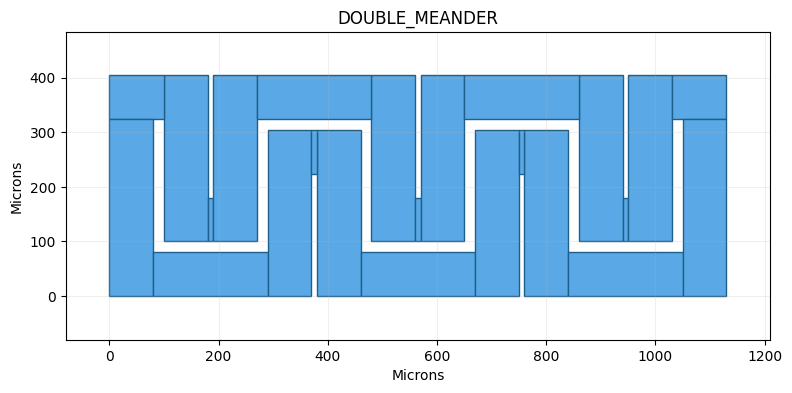

Output GDS: not saved
Cell: DOUBLE_MEANDER
Trace width (microns): 80
Gap width (microns): 10
Inner meander gap width (microns): 20
Leg count per lobe: 4
Total length (microns): 4988
Number of squares: 62.35
Outer cell height (microns): 304
Return cell height (microns): 304
Return bridge length (microns): 10
Bounding box (microns): 1130 x 404

Evaluated geometry:
GDS file: /tmp/tmpzui1sl45/DOUBLE_MEANDER.gds
Cells: DOUBLE_MEANDER
Layer filter: layer 1, datatype 0
Library unit (microns): 1
Area (square microns): 399040
Trace width (microns): 80
Effective length (microns): 4988
Number of squares: 62.35
Film thickness (nanometers): 30
Total volume (cubic microns): 11971.2


In [2]:
inductor_spec = gds.DoubleMeanderSpec(
    trace_width_microns=80.0,
    gap_width_microns=10.0,
    meander_inner_gap_width_microns=20.0,
    bounding_box_width_microns=1130.0,
    bounding_box_height_microns=404.0,
    layer=1,
)
inductor_built = gds.build_double_meander(inductor_spec)
inductor_built.plot()

inductor_eval = gds.evaluate_generated_double_meander(inductor_spec, save_path=None, film_thickness_nanometers=30.0)
print(inductor_eval)

In [3]:
finger_len_fracs = np.arange(1.0,0.0,-0.037)[:-1]
N_resonators = len(finger_len_fracs)
print(N_resonators, finger_len_fracs[0], finger_len_fracs[-1])

27 1.0 0.037999999999999146


In [4]:
idc_spec_list  = [None] * len(finger_len_fracs)
idc_built_list = [None] * len(finger_len_fracs)

for i, finger_len_f in enumerate(finger_len_fracs):

    idc_spec_list[i] = gds.IdcSpec(
        finger_count=15,
        finger_trace_width_microns=20.0,
        finger_length_microns=950.0,
        finger_gap_width_microns=20.0,
        arm_trace_width_microns=80.0,
        arm_gap_width_microns=10.0,
        bounding_box_width_microns=1130.0,
        final_finger_length_fraction=finger_len_f,
        include_bottom_bars=True,
        omit_top_arm_stubs=True,
        layer=2,
    )
    idc_built_list[i] = gds.build_idc(idc_spec_list[i])

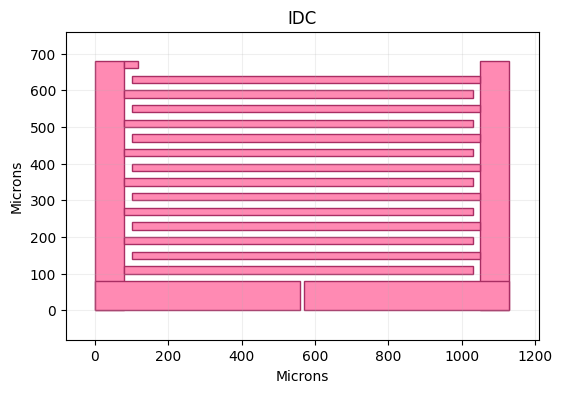

Output GDS: not saved
Cell: IDC
Finger count: 15
Left finger count: 8
Right finger count: 7
Finger trace width (microns): 20
Finger length (microns): 950
Final finger length fraction: 0.037999999999999146
Finger gap width (microns): 20
Finger tip gap width (microns): 20
Arm trace width (microns): 80
Arm gap width (microns): 10
Top arm stubs omitted: True
Bounding box (microns): 1130 x 680

Evaluated IDC geometry:
GDS file: /tmp/tmpxreychs9/IDC.gds
Cells: IDC
Layer filter: layer 2, datatype 0
Inferred capacitor model: idc
Inferred finger orientation: horizontal
Inferred finger count: 14
Adjacent finger pairs: 13
Inferred finger width (microns): 20
Inferred gap (microns): 20
Inferred pitch (microns): 40
Inferred finger length (microns): 950
Inferred active overlap length (microns): 930
Inferred active span (microns): 540
Inferred bounding box (microns): 970 x 540

Estimated IDC capacitance:
GDS file: /tmp/tmpxreychs9/IDC.gds
Cells: IDC
Layer filter: layer 2, datatype 0
Inferred capacitor

In [5]:
idc_idx = -1
idc_built = idc_built_list[idc_idx]
idc_spec  = idc_spec_list[idc_idx]

idc_built.plot()
print(gds.evaluate_generated_idc(idc_spec, save_path=None, effective_permittivity=9.08))

In [6]:
ground_shield_spec = gds.GroundShieldSpec(
    trace_thickness_microns=80,
    horizontal_gap_microns=20,
    upper_gap_microns=20,
    lower_gap_microns=20,
)

In [7]:
built_lekid_list = [None] * len(idc_spec_list)

for i, idc_spec in enumerate(idc_spec_list):
    built_lekid_list[i] = gds.build_double_meander_with_idc(
                            inductor_spec=inductor_spec,
                            idc_spec=idc_spec,
                            ground_shield_spec=ground_shield_spec,
                            )

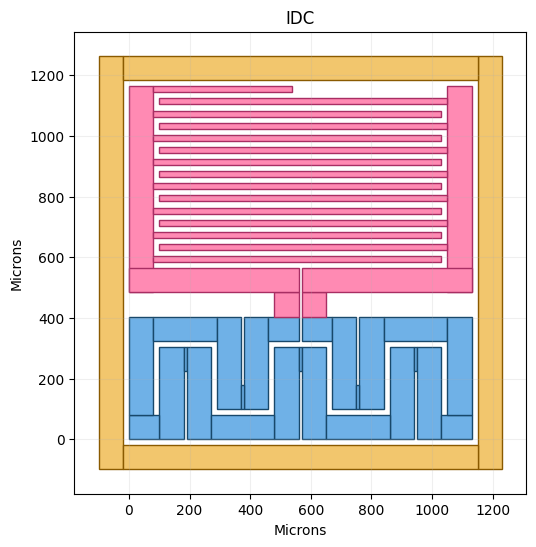

Output GDS: not saved
Cell: IDC
Inductor layer/datatype: 1/0
Capacitor layer/datatype: 2/0
Inductor trace width (microns): 80
Inductor gap width (microns): 10
Inductor leg count per lobe: 4
Inductor bounding box (microns): 1130 x 404
IDC finger count: 15
IDC finger trace width (microns): 20
IDC finger length (microns): 950
IDC finger gap width (microns): 20
IDC arm trace width (microns): 80
IDC arm gap width (microns): 10
IDC bottom bars included: True
IDC top arm stubs omitted: True
Bridge gap width (microns): 10
Assembly bounding box (microns): 1330 x 1364
Ground shield layer/datatype: 3/0
Ground shield trace thickness (microns): 80
Ground shield horizontal gap (microns): 20
Ground shield upper gap (microns): 20
Ground shield lower gap (microns): 20

Estimated resonator properties:
Geometric inductance estimation method: meander-aware-double
Requested meander mode: double
Film thickness (nanometers): 30
Inductor volume (cubic microns): 11947.2
Inductive area (square microns): 398240


In [8]:
lekid_idx = -13
built_lekid_list[lekid_idx].plot()

print( gds.evaluate_generated_double_meander_with_idc(built_lekid_list[lekid_idx], 
                                               effective_permittivity=9.08, 
                                               kinetic_inductance_per_square_nh=0.0, 
                                               film_thickness_nanometers=30.0
                                              ) )

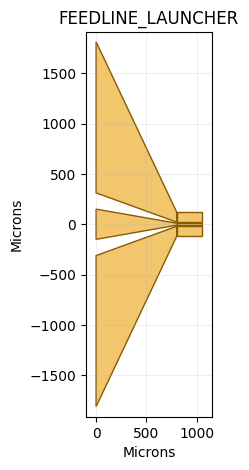

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'FEEDLINE_LAUNCHER'}, xlabel='Microns', ylabel='Microns'>)

In [9]:
fl_launch_spec = gds.FeedlineLauncherSpec(
    central_conductor_width_microns=20,
    gap_width_microns=10.75,
    ground_conductor_width_microns=100,
    signal_bond_pad_edge_width_microns=300,
    ground_bond_pad_edge_width_microns=1500,
    template_path="/home/dtemples/GDS-Geometry-Evaluator/assets/feedlines/feedline-launch-caltech-style.gds",
    layer=3,
    datatype=0,
)

fl_launch_built = gds.build_feedline_launcher(fl_launch_spec)
fl_launch_built.plot()

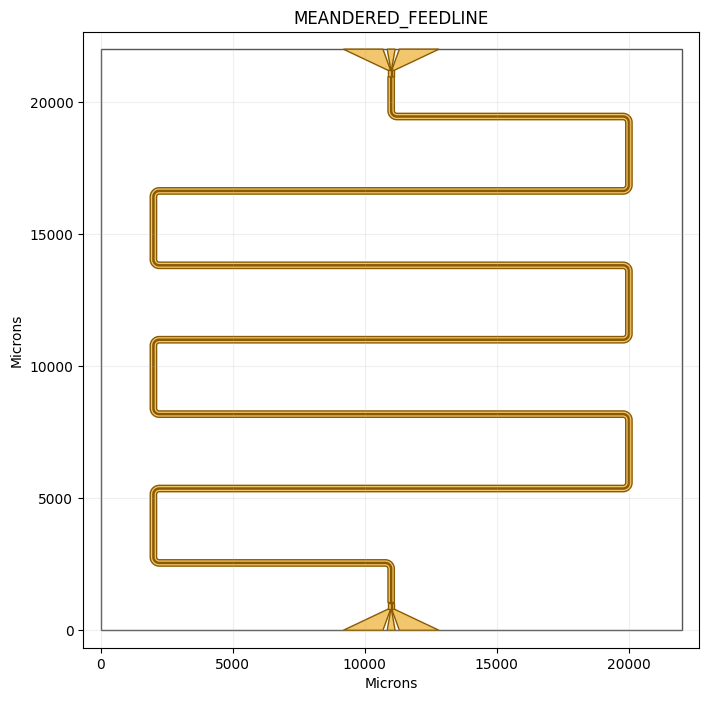

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'MEANDERED_FEEDLINE'}, xlabel='Microns', ylabel='Microns'>)

In [10]:
fl_spec = gds.MeanderedFeedlineSpec(
    launcher_spec=fl_launch_spec,
    chip_width_microns=22000,
    chip_height_microns=22000,
    face="top",
    row_count=5,
    first_stub_length_microns=1500.0,
    final_stub_length_microns=1500.0,
    full_run_length_microns=18000.0,
    offset_microns=0,
)

built_fl = gds.build_meandered_feedline(fl_spec)
built_fl.plot()

In [11]:
horiz_position_micron = [
                                   2000.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -6500.0, -3250.0, 0.0, 3250.0, 6500.0,
    -2000.0 
]

row_position = [         0,
                 1,1,1,1,1,
                 2,2,2,2,2,
                 3,3,3,3,3,
                 4,4,4,4,4,
                 5,5,5,5,5,
                 6,
]

orientation =  [         1,
                 -1,-1,-1,-1,-1,
                 1,1,1,1,1,
                 -1,-1,-1,-1,-1,
                 1,1,1,1,1,
                 -1,-1,-1,-1,-1,
                 1,
]

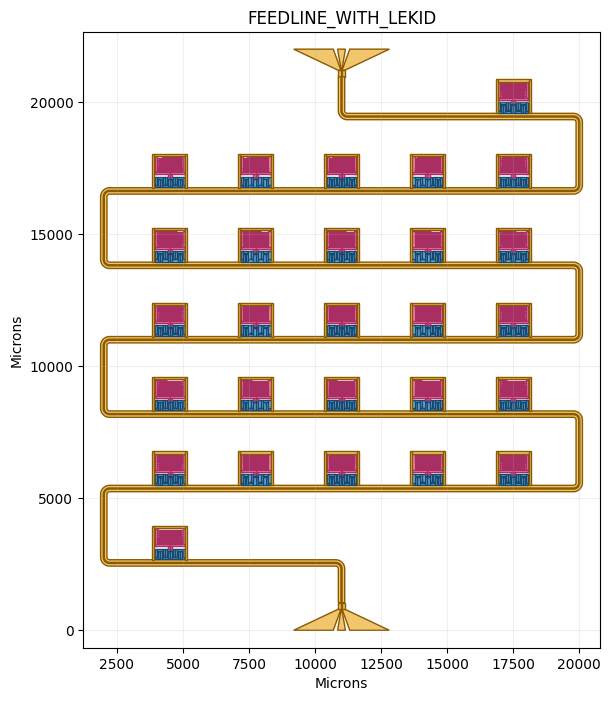

In [ ]:
placed = gds.place_lekid_on_feedline(
        feedline_result=built_fl,
        lekid_result=built_lekid_list[0],
        spec=gds.LekidFeedlinePlacementSpec(
            separation_microns=20.0,
            position_microns=horiz_position_micron[0],
            row_index=row_position[0],
        )
    )

for i_kid in range(1,N_resonators):
    placed = gds.place_lekid_on_feedline(
        placed,
        lekid_result=built_lekid_list[i_kid],
        spec=gds.LekidFeedlinePlacementSpec(
            separation_microns=20.0*orientation[i_kid],
            position_microns=horiz_position_micron[i_kid],
            row_index=row_position[i_kid],
        ),
    )
    
placed.plot()

gds.write_built_gds("./MLA5G-Inductor-FingerTune-FullChip.gds", placed)